# QvaPay Challenge accepted

## Requerimientos

In [237]:
import requests
import json
import pandas as pd
from datetime import datetime
import plotly.express as px
from ipywidgets import widgets, Output, interact, Text, VBox
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from random import randint

## Exploración de datos
 

### Manejo de la base de datos

Comenzamos almacenando la base de datos que solicitamos de la API de de QvaPay de transacciones P2P. Como está paginada, es necesario el uso de un bucle que sucesivamente incluye la información que solicita de la página siguiente, cuya URL cual nos es proporcionada en uno de los campos de cada página.

In [233]:
base=[]
path="https://qvapay.com/api/p2p"

def get_data(path):
    response = requests.get(path)
    return response.json()

while path != None:
    data = get_data(path)
    base.extend(data['data'])
    path=data['next_page_url']

print(f'Cantidad de ofertas activas: {len(base)}')

Cantidad de ofertas activas: 1385


Adicionalmente, puede resultar conveniente almacenar la base de datos localmente, debidamente etiquetada con la fecha y la hora de consulta para mayor comodidad.

In [234]:
current_time = datetime.now()
filename_date = current_time.strftime("%Y-%m-%d_%H-%M-%S")

with open(f"base{filename_date}.json", "w") as file:
    json.dump(base, file, indent=4)

print("Dataset saved as "f"base{filename_date}.json")

Dataset saved as base2025-01-15_18-19-12.json


Mudamos la base al entorno de la librería 'pandas'. Con ello disfrutaremos de una visualización más cómoda de los datos, así como de un manejo más eficiente. 

In [235]:
base_df = pd.DataFrame(base)
print(len(base_df))

1385


Finalmente, realizamos un filtrado de la base de datos que nos permite deshacernos de los campos embebidos y datos redundantes. A partir de este momento, sobre cada entrada de la base (es decir, oferta activa en la plataforma) analizaremos:
- id único
- fecha (sin incluir hora)
- usuario
- moneda
- tipo de transacción (compra/venta)
- monto en UST
- monto que se pide (_ask_) o se ofrece (_bid_) por el monto en USDT
- precio del USDT en la transacción (el cual se calcula a partir de los últimos dos datos) 

In [242]:
base_df["date"] = base_df["updated_at"]

filtered_base = pd.DataFrame({
    'id': base_df['uuid'],
    'date': pd.to_datetime(base_df['date']).dt.date,  # Keep only the date (first 10 characters)
    'user': base_df['owner'].apply(lambda x: x['username']),  # Extract 'name' from 'user_from'
    'coin': base_df['coin'],
    'type': base_df['type'],
    'amount': pd.to_numeric(base_df["amount"]),
    'receive': pd.to_numeric(base_df["receive"]),
})

filtered_base['price']= filtered_base["receive"]/filtered_base["amount"]
filtered_base['date']

0       2025-01-15
1       2025-01-15
2       2025-01-15
3       2025-01-15
4       2025-01-15
           ...    
1380    2023-11-29
1381    2023-11-28
1382    2023-11-28
1383    2023-11-28
1384    2023-12-14
Name: date, Length: 1385, dtype: object

### Análisis descriptivo de los datos

A continuación se muestra un gráfico interactivo que posibilita explorar en cada fecha las ofertas activas de compra o venta en cada moneda, especificando el precio por USDT y el monto.

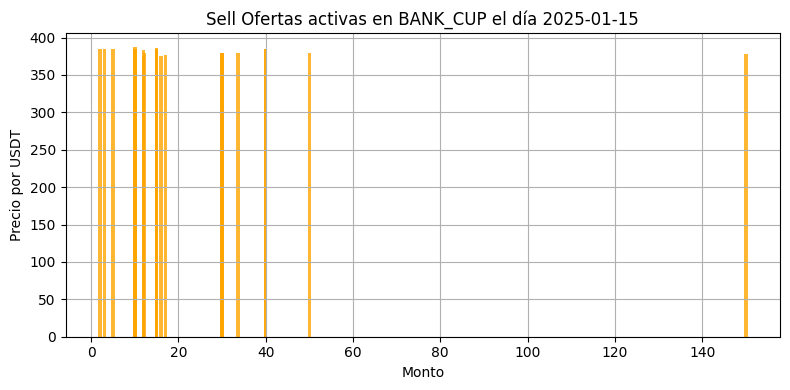

No hay datos de ofertas disponibles en NEOMOON el día 2025-01-12 (sell)


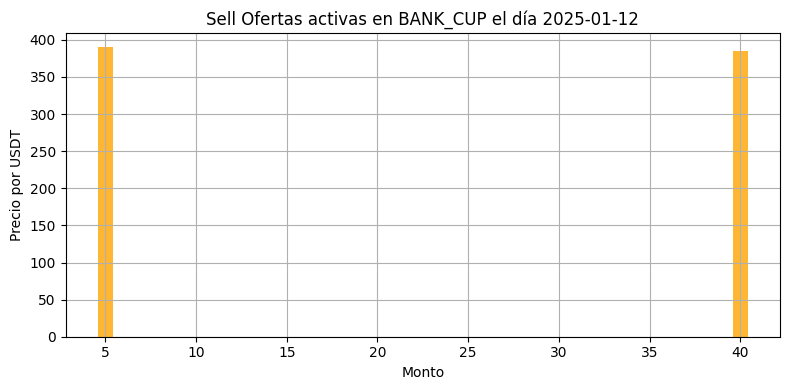

No hay datos de ofertas disponibles en BANK_MLC el día 2025-01-12 (sell)


In [224]:
# Create an output widget
output = Output()

# Function to filter and plot price vs. amount
def update_chart(selected_coin, selected_date, tran_type):        
        # Filter dataset based on dropdown selections
        filtered_data = filtered_base[
            (filtered_base['coin'] == selected_coin) & 
            (filtered_base['date'] == selected_date) &
            (filtered_base['type'] == tran_type)
        ]

        if filtered_data.empty:
            print(f"No hay datos de ofertas disponibles en {selected_coin} el día {selected_date} ({tran_type})")
            return
        
        # Create the plot
        fig, ax = plt.subplots(figsize=(8, 4))
        
        # Scatter plot: amount on x-axis, price on y-axis
        ax.bar(filtered_data['amount'], filtered_data['price'], color='orange', alpha=0.8)
        
        # Configure plot
        ax.set_xlabel('Monto')
        ax.set_ylabel('Precio por USDT')
        ax.set_title(f'{tran_type.capitalize()} Ofertas activas en {selected_coin} el día {selected_date}')
        ax.grid(True)
        plt.tight_layout()
        
        output.clear_output()
        plt.show()

# Dropdown widgets
coin_dropdown = widgets.Dropdown(options=filtered_base['coin'].unique(), description='Coin:')
date_dropdown = widgets.Dropdown(options=filtered_base['date'].unique(), description='Date:')
type_dropdown = widgets.Dropdown(options=filtered_base['type'].unique(), description='Type:')

# Callback function to handle updates
def on_change(change=None):
    update_chart(coin_dropdown.value, date_dropdown.value, type_dropdown.value)

# Attach listeners to dropdown changes
coin_dropdown.observe(on_change, names='value')
date_dropdown.observe(on_change, names='value')
type_dropdown.observe(on_change, names='value')

# Layout: Dropdowns + Output
ui = VBox([coin_dropdown, date_dropdown, type_dropdown, output])

# Initial chart update
update_chart(coin_dropdown.value, date_dropdown.value, type_dropdown.value)

# Display the UI
display(ui)

Como análisis exploratorio de la circulación diaria de monedas en la plataforma, calculamos a continuación algunas medidas estadísticas generales.

In [225]:
# Group by coin, date, and type, and sum the amounts
grouped_data = (
    filtered_base
    .groupby(['coin', 'date', 'type'])
    .agg(
        total_amount=('receive', lambda x: x.sum()),  # Total bought/sold
        mean_price=('price', lambda x: x.mean() if len(x) > 0 else 'none'),  # Mean price
        price_variance=('price', lambda x: x.var(ddof=0) if len(x) > 1 else 'none')  # Variance of price
    )
    .unstack(fill_value=0)
    .reset_index()
)

# Rename columns
grouped_data.columns = ['Moneda', 'Fecha', 'Total de oferta para compra', 'Total de oferta para venta', 'Precio medio de compra', 'Precio medio de venta', 'Varianza del precio de compra', 'Varianza del precio de venta']

# Create an output widget
output = Output()

# Function to display the table based on the selected date
def update_table(change=None):
        output.clear_output()
        
        # Get the selected date
        selected_date = date_dropdown.value
        selected_type = type_dropdown.value
        
        # Filter the grouped data by the selected date
        filtered_table = grouped_data[grouped_data['Fecha'] == selected_date]
        filtered_table = grouped_data[grouped_data['Fecha'] == selected_date]
        
        # Display the filtered table
        if filtered_table.empty:
            print(f"No hay datos disponibles el día {selected_date}")
        else:
            print(filtered_table)

# Create a dropdown for date selection
date_dropdown = widgets.Dropdown(
    options=grouped_data['Fecha'].unique(),
    description='Fecha:',
    value=grouped_data['Fecha'].unique()[0]  # Default to the first date
)

type_dropdown = widgets.Dropdown(
    options=filtered_base['type'].unique(),
    description='Tipo de oferta:',
    value=filtered_base['type'].unique()[0]  # Default to the first date
)

# Attach the observer to the dropdown
date_dropdown.observe(update_table, names='value')
type_dropdown.observe(update_table, names='value')

# Initialize the table display
update_table()

# Display the UI
ui = VBox([date_dropdown, type_dropdown, output])
display(ui)

        Moneda       Fecha  Total de oferta para compra  \
0    APPLECASH  2025-01-12                       100.00   
277   BANK_CUP  2025-01-12                    231940.00   
452   BANK_MLC  2025-01-12                      2624.94   
580     QVAPAY  2025-01-12                      3600.00   
595   TELEGRAM  2025-01-12                       850.00   
631   TROPIPAY  2025-01-12                        50.00   
688    USDCASH  2025-01-12                        40.00   
749      ZELLE  2025-01-12                       100.00   

     Total de oferta para venta  Precio medio de compra  \
0                           0.0                1.000000   
277                     17350.0              369.875989   
452                         0.0                1.543000   
580                         0.0              360.000000   
595                         0.0               85.000000   
631                         0.0                0.909091   
688                         0.0                1.000000

In [231]:
A=['ETECSA','BOLSATM','RevoluPay','BANK_CUP','BANK_MLC','CUPCASH'] #Monedas de uso nacional
B=[item for item in filtered_base['coin'].unique() if item not in national_coins] #Otras monedas

# Calcular el total de dinero movido por cada user en compras y ventas
total_buys = filtered_base[filtered_base['type'] == 'buy'].groupby('user')['amount'].sum()
total_sells = filtered_base[filtered_base['type'] == 'sell'].groupby('user')['amount'].sum()

# Calcular porcentajes de dinero movido por tipo de operación y moneda
filtered_base['buy_A'] = filtered_base.apply(lambda x: x['amount'] if x['type'] == 'buy' and x['coin'] in A else 0, axis=1)
filtered_base['sell_A'] = filtered_base.apply(lambda x: x['amount'] if x['type'] == 'sell' and x['coin'] in A else 0, axis=1)
filtered_base['buy_B'] = filtered_base.apply(lambda x: x['amount'] if x['type'] == 'buy' and x['coin'] in B else 0, axis=1)
filtered_base['sell_B'] = filtered_base.apply(lambda x: x['amount'] if x['type'] == 'sell' and x['coin'] in B else 0, axis=1)

# Agrupar por user y calcular sumas
grouped = filtered_base.groupby('user').sum()

# Calcular porcentajes
grouped['buy_A_pct'] = grouped['buy_A'] / total_buys * 100
grouped['sell_A_pct'] = grouped['sell_A'] / total_sells * 100
grouped['buy_B_pct'] = grouped['buy_B'] / total_buys * 100
grouped['sell_B_pct'] = grouped['sell_B'] / total_sells * 100

# Reemplazar NaN por 0 en porcentajes
grouped.fillna(0, inplace=True)

# Añadir total de transacciones por user
grouped['total_transacciones'] = filtered_base.groupby('user').size()

# Seleccionar y reorganizar columnas
result = grouped[['buy_A_pct', 'sell_A_pct', 'buy_B_pct', 'sell_B_pct', 'total_transacciones']]

# Mostrar resultados
result.reset_index()

,user,buy_A_pct,sell_A_pct,buy_B_pct,sell_B_pct,total_transacciones
0,$abreudariel,100.0,0.0,0.0,0.0,1
1,$amilenam,100.0,0.0,0.0,0.0,2
2,$darcy03,100.0,0.0,0.0,0.0,1
3,$davidhr,100.0,0.0,0.0,0.0,2
4,$elTony88,100.0,0.0,0.0,0.0,2
...,...,...,...,...,...,...
1037,yury2217,100.0,0.0,0.0,0.0,1
1038,yusiesmiamor,100.0,0.0,0.0,0.0,1
1039,zaldiv90,100.0,0.0,0.0,0.0,1
1040,zuritayoan84,100.0,0.0,0.0,0.0,1


In [227]:
def plot_user_transactions(user):
    # Filter data for the selected user
    user_data = filtered_base[filtered_base['user'] == user]
    
    if user_data.empty:
        print(f"No transactions found for user: {user}")
        return
    
    # Calculate cumulative stock
    user_data['cumulative_stock'] = user_data.apply(
        lambda row: row['amount'] if row['type'] == 'buy' else -row['amount'], axis=1
    ).cumsum()

    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Get unique days
    unique_days = user_data['date'].unique()
    
    # Draw day separators
    for idx, day in enumerate(unique_days):
        day_data = user_data[user_data['date'] == day]
        start = day_data.index[0] - 0.5
        end = day_data.index[-1] + 0.5
        color = 'lightgray' if idx % 2 == 0 else 'white'
        ax.add_patch(Rectangle((start, ax.get_ylim()[0]), end - start, ax.get_ylim()[1] - ax.get_ylim()[0], color=color, alpha=0.2))
    
    # Plot floating bars for each transaction
    prev_stock = 0  # Start cumulative stock at 0
    for i, row in user_data.iterrows():
        new_stock = prev_stock + (row['amount'] if row['type'] == 'buy' else -row['amount'])
        color = 'green' if row['type'] == 'buy' else 'gray'
        
        # Plot a bar from the previous stock to the new stock
        ax.bar(i, new_stock - prev_stock, bottom=prev_stock, color=color, label='Buy' if color == 'green' else 'Sell')
        
        prev_stock = new_stock  # Update the stock
    
    # Configure plot
    ax.set_xticks(user_data.index)
    #ax.set_xticklabels(f'{user_data['date']}', rotation=45)
    ax.set_ylabel('Stock')
    ax.set_xlabel('Transactions')
    ax.set_title(f'Transactions for User: {user}')
    ax.legend(['Buy', 'Sell'])
    plt.tight_layout()
    plt.show()

# Interactive widget to input user name
interact(plot_user_transactions, user=Text(value='Alice', description='User:'))

interactive(children=(Text(value='Alice', description='User:'), Output()), _dom_classes=('widget-interact',))

<function __main__.plot_user_transactions(user)>

In [228]:
# Ensure 'amount' is converted to a numeric type
filtered_base['amount'] = pd.to_numeric(filtered_base['amount'], errors='coerce')

# Calculate User Profits
def calculate_user_profits(filtered_base):
    # Separate buys and sells
    buys = filtered_base[filtered_base['type'] == 'buy']
    sells = filtered_base[filtered_base['type'] == 'sell']
    
    # Aggregate buy and sell amounts and values by user and coin
    buy_stats = buys.groupby(['user', 'coin']).agg(
        total_buy_amount=('amount', 'sum'),
        total_buy_value=('price', lambda x: (x * buys.loc[x.index, 'amount']).sum())
    )
    sell_stats = sells.groupby(['user', 'coin']).agg(
        total_sell_amount=('amount', 'sum'),
        total_sell_value=('price', lambda x: (x * sells.loc[x.index, 'amount']).sum())
    )
    
    # Merge buy and sell stats
    user_stats = buy_stats.join(sell_stats, how='outer').fillna(0)
    
    # Calculate profits
    user_stats['profit'] = user_stats['total_sell_value'] - user_stats['total_buy_value']
    user_stats['net_amount'] = user_stats['total_sell_amount'] - user_stats['total_buy_amount']
    return user_stats

# Calculate Spreads
def calculate_spreads(filtered_base):
    # Group by coin and date, and calculate the bid-ask spread
    spread_stats = filtered_base.groupby(['coin', 'date']).agg(
        highest_bid=('price', lambda x: max(x[filtered_base.loc[x.index, 'type'] == 'buy'], default=0)),
        lowest_ask=('price', lambda x: min(x[filtered_base.loc[x.index, 'type'] == 'sell'], default=0))
    )
    spread_stats['spread'] = spread_stats['highest_bid'] - spread_stats['lowest_ask']
    return spread_stats

# Execute Analysis
user_profits = calculate_user_profits(filtered_base)
spreads = calculate_spreads(filtered_base)

# Display Results
print("User Profits:")
print(user_profits)

print("\nMarket Spreads:")
print(spreads)


User Profits:
                       total_buy_amount  total_buy_value  total_sell_amount  \
user         coin                                                             
$abreudariel BANK_CUP             12.00           4080.0                0.0   
$amilenam    BANK_CUP             30.00          10200.0                0.0   
$darcy03     BANK_CUP             30.00           9900.0                0.0   
$davidhr     BANK_CUP             10.65           3210.0                0.0   
$elTony88    BANK_CUP            150.00          53000.0                0.0   
...                                 ...              ...                ...   
yury2217     ETECSA               22.00          10000.0                0.0   
yusiesmiamor BANK_CUP             25.00           9000.0                0.0   
zaldiv90     BANK_CUP              5.00           1650.0                0.0   
zuritayoan84 BANK_CUP              1.00            340.0                0.0   
🥰❤️💯         ETECSA                3.3

## Inferencias de interés